In [1]:
import torch.nn as nn
from black_scholes.sobolev.bs_sobolev_nd import BlackScholesSobolevMultiAsset
from utility.model import EarlyStopping, ModelConfig
from config.bs_sobolev_nd import *

In [2]:
seeds = [24]
for seed in seeds:
    print(f'Training model with seed {seed}...')
    model = BlackScholesSobolevMultiAsset(model_config, seed=seed)
    model.set_params(K, r, sigmas, corr, T, S_mins, S_maxs)
    model.set_loss_weights(loss_weights)
    early_stopping = EarlyStopping(patience=1000, min_delta=1e-7)
    model.train(batch_size=4096, epochs=30000, early_stopping=early_stopping, anneal_freq=1000, alpha=0.9)
    model.save(f'../../models/bs_sobolev_nd/{seed}.pth')

Training model with seed 24...
Iter      0 | Train: 1.2520e+00 | Val: 1.1415e+00 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter    500 | Train: 1.3446e-02 | Val: 2.3868e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   1000 | Train: 8.7183e-03 | Val: 1.6529e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   1500 | Train: 8.2356e-03 | Val: 1.2999e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   2000 | Train: 4.9147e-03 | Val: 1.4679e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   2500 | Train: 6.0355e-03 | Val: 1.0367e-02 | Weights: pde=0.250  J2=0.417  J3=0.250  J4=0.083
Iter   3000 | Train: 4.1891e-03 | Val: 1.0422e-02 | Weights: pde=0.558  J2=0.139  J3=0.219  J4=0.083
Iter   3500 | Train: 3.5689e-03 | Val: 9.0442e-03 | Weights: pde=0.558  J2=0.139  J3=0.219  J4=0.083
Iter   4000 | Train: 4.4421e-03 | Val: 9.0104e-03 | Weights: pde=0.353  J2=0.228  J3=0.336  J4=0.083
Iter   4500 | Train: 4.2561e-03 | Val: 8.2103e-03 | Weights:

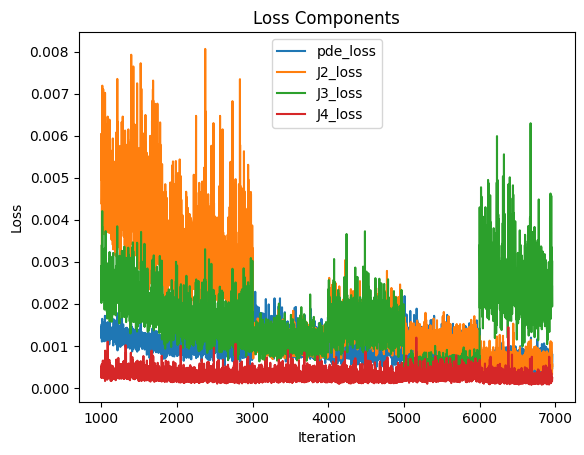

In [3]:
model.plot_losses(detailed=True, start_epoch=1000)